# 환경설정

In [ ]:
# Colab에는 TensorFlow가 기본 설치되어 있습니다.
import sys
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

# 라이브러리 불러오기
- 파이썬 머신러닝 기본 라이브러리 : Scikit-Learn
- 파이썬 딥러닝 라이브러리
  + Tensorflow : (2015), Google
    - 1.x 버전 : 초창기에는 많이 선점했으나, Pytorch 등장 이후에 바로 밀림, 문법 자체가 완전히 새로운 프로그래밍 언어
      + 초창기에는 Tensorflow 활용한 프로젝트 많이 진행
    - 2.x 버전 : (2019) 새로 나옴, Numpy 문법 유사
  + Pytorch : (2017), Meta => 리눅스 재단 오픈소스화해서 넘김 (2022)
    - Numpy 문법 유사 => 많은 사람들이 사용하기 시작함
    - 각 대학 Lab실, 연구실쪽은 대세 언어가 됨

In [ ]:
# CPU 및 GPU(Cuda)를 활용하여 텐서(Tensor)를 생성하고 관리하는 핵심 엔진
import torch

# GPU 그래픽 카드 설치했는데요! => Nvidia 개발자 센터 활용해서 별도 설치 진행
# 신경망 구조 설계하는 모듈
# - nn.Linear(선형 레이어) 등 활용
# - 과적합 방지 몇 가지 장치
# - 배치 정규화, 드롭아웃 등 레이어 등이 내장되어 있음
import torch.nn as nn

# 경사하강법의 여러 종류들 호출
# - 최적화 알고리즘 모듈
# - Adam 알고리즘 기본값 활용
import torch.optim as optim

# 각 레이어들의 가중치 초기값 설정 시 필요한 모듈
# - 학습 초기 단계 : 초기값 설정 시, 임의로 주기 때문에, 왜곡될 가능성 농후
# -- 효율이 극대화 되도록 밸런스 유지
import torch.nn.init as init

# DataLoader : 학습 데이터를 가공하여 모델에 효율적으로 공급하는 유틸리티
# - 미니 배치(Mini-Batch) 구현
# - 데이터를 편향 없이 골고루 배우도록 무작위로 섞는 셔플 기능 담당
from torch.utils.data import DataLoader

# 이미지 및 비디오 처리(Computer Vision)에 특화된 패키지
# - 샘플 데이터셋 다운로드 역할
import torchvision

# 데이터 가공
# - ToTensor() : 일반 이미지 파일(0 ~ 255) => Pytorch가 계시 가능한 텐서로 변환
# - Normalize() : 이미지 데이터의 평균과 표준편차를 맞춰주어 학습의 안정성 배치 정규화 효과를 극대화
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

# 가장 중요한 핵심
# - 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


# 데이터셋 불러오기 및 전처리

In [ ]:
# 이미지를 텐서 형태로 바꾸고, 모델이 학습하기 좋은 분포로 정규화
# 데이터 처리 파이프라인 생성
transform = transforms.Compose([
    transforms.ToTensor(),  # 0~255 사이의 픽셀 값을 0.0~1.0 사이의 float32 텐서로 변환합니다
    transforms.Normalize((0.5,), (0.5,))  # 평균 0.5, 표준편차 0.5를 기준으로 정규화하여 데이터를 -1.0~1.0 범위로 맞춥니다
])

# torchvision 활용해서 Fashion MNIST 데이터셋 자동으로 다운로드
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 미니배치 설정
# - 미니배치란?
# - 세탁기 용량 20kg => 알고리즘 용량
# - 빨래 50kg
#
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 다양한 이미지 정리
# Fashion MNIST의 고유 라벨(0~9)을 사람이 읽을 수 있는 텍스트 문자열로 변환하기 위한 리스트입니다.
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

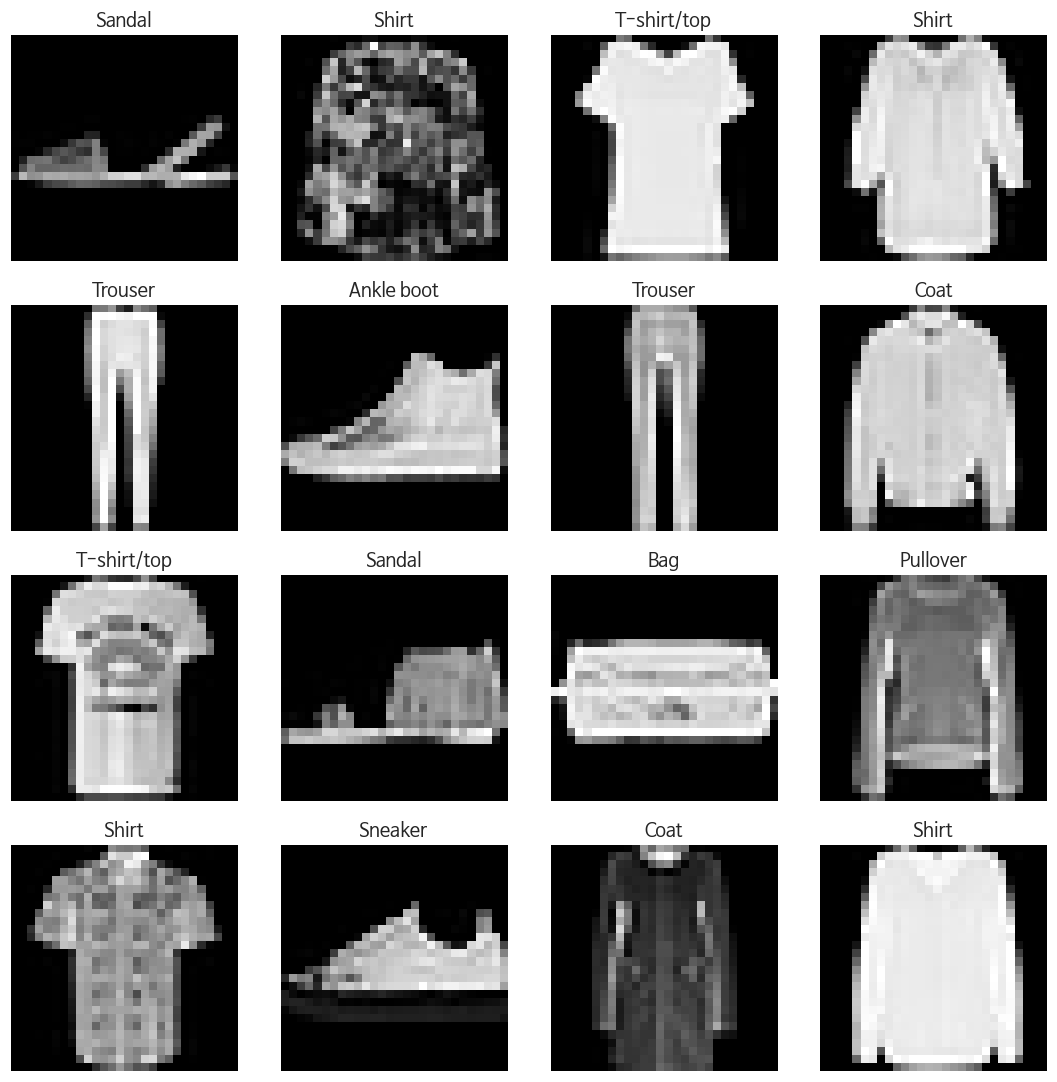

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 2. 무작위 샘플 이미지 시각화
# ==========================================

# train_loader에서 첫 번째 배치(64개 이미지)를 꺼내옵니다.
# shuffle=True 상태이므로 매번 실행할 때마다 다른 무작위 샘플이 나옵니다.
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 시각화할 이미지 개수 설정 (행과 열)
rows, cols = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

for i in range(rows * cols):
    # 각 subplot 위치 계산

    ax = axes[i // cols, i % cols]

    # 텐서에서 이미지와 라벨 추출
    img = images[i]
    label = labels[i].item()

    # [전처리 역산] matplotlib으로 그리려면 0~1 사이의 값이어야 합니다.
    # 원래 식: (x - 0.5) / 0.5 -> 역산 식: x * 0.5 + 0.5
    img = img * 0.5 + 0.5

    # 파이토치 차원 (채널, 높이, 너비) -> 넘파이 및 채널 압축 (높이, 너비)
    # Fashion MNIST는 흑백(1채널)이므로 squeeze()로 1 차원을 제거합니다.
    img = img.squeeze().numpy()

    # 이미지 출력 및 제목 설정
    ax.imshow(img, cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')  # 축 눈금 숨기기


plt.tight_layout()
plt.show()

# MyMLP 모델 만들기
- 오늘 수업의 핵심
- 아키텍쳐를 만든다!
  + 딥러닝 쪽에서는 이거 자체가 논문 주제

In [ ]:
# myMLP 모델 정의 (다층 퍼셉트론 신경망)
class myMLP(nn.Module):
  def __init__(self):
    super(myMLP, self).__init__()

    self.mlp = nn.Sequential(
      # 아키텍쳐 구성
      # 차원변환 Fashion MNIST 이미지 28X28 해상도
      # MLP는 1차원 벡터만 입력받을 수 있으므로, 28X28 일렬로 쭉 늘이기
      # 784개의 피처로 반환 (784개의 컬럼)
      nn.Flatten(), # ==> 입력층

      # 은닉층 1 (Hidden Layer)
      nn.Linear(784, 512),  # 입력 피쳐 784개, 512개의 특징으로 확장함

      # 배치 정규화 (Batch Normalization)
      # 과적합 억제
      # 학습속도 대폭 향상
      # 입력층의 값들이 현재 1차원 값
      nn.BatchNorm1d(512),

      # 활성화 함수
      # - 기존 Sigmoid/Tanh 함수 등은 기울기 소실 문제를 야기
      # - ReLU는 입력이 양수일 때, 미분값이 항상 1, 깊은 레이어에서도 오차를 소실 없이 전파한다
      nn.ReLU(),

      # 드롭아웃 (Dropout)
      # - 비유 : 고장난 일부 뉴런을 제거
      # - 학습 도중 매 스텝마다 30%의 뉴런을 임의로 제거
      # - "특정 뉴런에 과도하게 의존"하는 과적합(Overfitting) 방지
      nn.Dropout(0.3),

      # 은닉층 2 (Hidden Layer2)
      nn.Linear(512, 256),  # 입력 피쳐 512개, 256개의 특징으로 확장함
      nn.BatchNorm1d(256),
      nn.ReLU(),
      nn.Dropout(0.3),

      # 출력층
      nn.Linear(256, 10)  # 입력 피쳐 256개, 10개의 클래스로 확장함

    )

    # 가중치 초기화 적용 (Weight Initialization)
    self._init_weights()


  def _init_weights(self):
    # 모델 내부의 모든 서브 모듈을 돌며 선형 레이어(nn.Linear)를 찾아 초기화 알고리즘을 수행합니다.
    for m in self.modules():
      if isinstance(m, nn.Linear):
        # He 초기화 (Kaiming Normal)
        # 기존의 표준정규분포 초기화는 레이어가 깊어질수록 출력 값을 0으로 수렴하게 만드는 문제가 있습니다
        # He 초기화는 입력 개수 절반의 제곱근을 고려하여 가중치를 채우므로, ReLU 함수와 결합했을 때 가장 안정적이고 효율적인 학습을 보장합니다
        init.kaiming_normal_(m.weight, nonlinearity='relu')

        # 편향(Bias) 값은 학습 초기 편향을 주지 않기 위해 모두 0으로 안전하게 채워둡니다.
        if m.bias is not None:
          init.constant_(m.bias, 0)

  def forward(self, x):
    # 정의된 mlp Sequential 흐름에 따라 순전파(Forward Propagation)를 수행합니다.
    return self.mlp(x)

# 생성한 myMLP 모델 인스턴스를 지정한 연산 장치(CPU 혹은 GPU)로 전송합니다.
model = myMLP().to(device)
model

myMLP(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=10, bias=True)
  )
)

# 손실함수 및 최적화 알고리즘

In [ ]:
# 다중 클래스 분류 문제 => 교차 엔트로피 정의
# 내부에 Softmax 함수가 내장되어 있음
criterion = nn.CrossEntropyLoss()

# Adam 알고리즘
# SGD => (여러 알고리즘 존재) => Adam으로 정리가 됨
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 모델 학습

In [ ]:
# 모델 학습
epochs = 5
print("myMLP 모델 학습 시작")

# 명시적 모드로 전환
model.train()

for epoch in range(epochs):
  running_loss = 0.0

  # 전체 데이터셋을 미니 배치 크기 단위로 나누어서 가져오기
  for images, labels in train_loader:
    # 데이터와 라벨로 CPU/GPU 환경으로 보내기
    images, labels = images.to(device), labels.to(device)

    # 1) 이전 미니 배치에서 계산되어 있던, 가중치의 기울기를 0으로 초기화
    optimizer.zero_grad()

    # 2) 모델에 이미지를 입력, 예측값을 산출 (순전파)
    outputs = model(images)

    # 3) 예측값과 실제 정답(Labels) 간의 오차 계산
    loss = criterion(outputs, labels)

    # 4) 오차를 바탕으로 역전파 수행
    loss.backward()

    # 5) 계산된 기울기와 Adam 알고리즘 규칙에 따른 모델의 가중치를 실제 업데이트
    optimizer.step()

    # 에포크 전체 손실값을 구하기 위해 현재 미니 배치의 손실(평균값)에 배치 크기를 곱해 누적합니다.
    running_loss += loss.item() * images.size(0)

  # 에포크 종료 후 전체 데이터 개수로 나누어 평균 손실을 산출하고 출력합니다.
  epoch_loss = running_loss / len(train_loader.dataset)
  print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")



myMLP 모델 학습 시작
Epoch [1/5], Loss: 0.5057
Epoch [2/5], Loss: 0.3891
Epoch [3/5], Loss: 0.3534
Epoch [4/5], Loss: 0.3314
Epoch [5/5], Loss: 0.3134


# 모델 평가

In [ ]:
# ==========================================
# 5. 모델 평가 및 평가지표(Metrics) 구현
# ==========================================
# 모델을 평가 모드로 전환합니다. (중요: Dropout이 비활성화되며, BatchNorm은 고정된 학습 데이터 통계치를 사용함)
model.eval()

all_preds = []
all_labels = []
all_images = []

# 평가 단계에서는 역전파를 위한 기울기 계산(Gradient Tracking)이 불필요하므로 차단하여 메모리를 절약하고 속도를 높입니다.
with torch.no_grad():
  for images, labels in test_loader:
    images_dev, labels_dev = images.to(device), labels.to(device)

    # 모델의 예측 결과를 가져옵니다.
    outputs = model(images_dev)

    # 10개의 출력 로짓 중 가장 높은 점수(확률)를 가진 인덱스 번호를 최종 예측 클래스로 채택합니다.
    _, preds = torch.max(outputs, 1)

    # 나중에 분석 및 시각화를 하기 위해 넘파이 배열 형태로 정답, 예측값, 원본 이미지를 차곡차곡 누적합니다.
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())
    all_images.extend(images.numpy())

# 리스트를 다루기 편한 NumPy 배열로 최종 변환합니다.
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_images = np.array(all_images)

# 평가지표 산출 및 출력
print("\n=== 모델 최종 평가 지표 ===")
# 전체 데이터 중 올바르게 분류한 비율을 나타내는 Accuracy(정확도)를 계산합니다.
print(f"전체 Accuracy (정확도): {accuracy_score(all_labels, all_preds):.4f}")
print("\n[상세 분류 리포트 (Precision, Recall, F1-Score)]")
# 클래스별 정밀도(Precision), 재현율(Recall), F1-스코어를 상세하게 보여주는 스킬런 리포트입니다.
print(classification_report(all_labels, all_preds, target_names=class_names))


=== 모델 최종 평가 지표 ===
전체 Accuracy (정확도): 0.8849

[상세 분류 리포트 (Precision, Recall, F1-Score)]
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.85      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.82      0.80      0.81      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.79      0.83      0.81      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.71      0.70      0.70      1000
     Sneaker       0.94      0.93      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



# 테스트

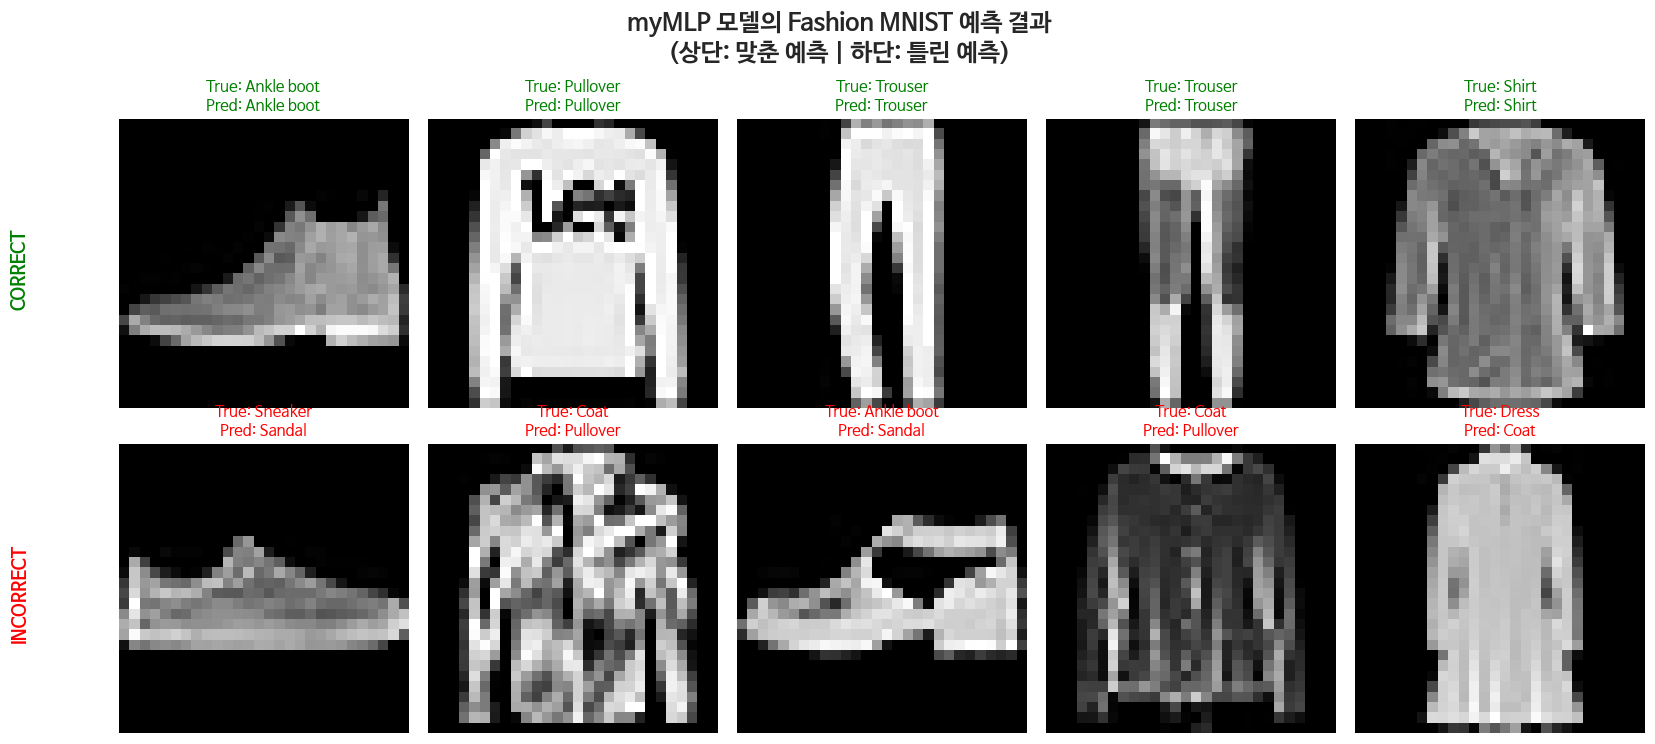

In [ ]:
# ==========================================
# 6. fig, ax를 이용한 맞춘 것과 틀린 것 구분 시각화
# ==========================================
# 정답과 예측값이 똑같은 인덱스(맞춘 샘플)와 서로 다른 인덱스(틀린 샘플)를 넘파이 조건문으로 완벽히 분리합니다.
correct_indices = np.where(all_preds == all_labels)[0]
incorrect_indices = np.where(all_preds != all_labels)[0]

# 객체지향형 시각화를 위해 matplotlib의 fig와 axes(2행 5열 서브플롯 배열) 객체를 생성합니다.
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

# 전체 대제목 설정
fig.suptitle("myMLP 모델의 Fashion MNIST 예측 결과\n(상단: 맞춘 예측 | 하단: 틀린 예측)", fontsize=16, fontweight='bold')

# ----------------------------------
# 1층 (첫 번째 행): 성공적으로 맞춘 예측 (Correct) 5개 그리기
# ----------------------------------
for i in range(5):
    ax = axes[0, i]             # 0번째 행의 i번째 열 축을 선택합니다.
    idx = correct_indices[i]    # 맞춘 샘플들 중 앞에서부터 하나씩 인덱스를 가져옵니다.
    img = all_images[idx].squeeze() # (1, 28, 28) 형태의 채널 차원을 없애 2D 이미지 (28, 28)로 만듭니다.

    ax.imshow(img, cmap='gray') # 흑백 이미지 스타일로 플롯에 띄웁니다.
    # 상단 서브플롯 제목을 초록색(green)으로 설정하여 성공을 가시화합니다.
    ax.set_title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}", color='green', fontsize=10)
    ax.axis('off')              # 눈금선과 축 수치를 지워 깔끔하게 이미지 만 보여줍니다.

    # 첫 번째 열의 이미지 왼쪽에 행을 대표하는 라벨 텍스트를 세로로 삽입합니다.
    if i == 0:
        ax.text(-10, 14, "CORRECT", va='center', ha='center', rotation='vertical', fontsize=12, fontweight='bold', color='green')

# ----------------------------------
# 2층 (두 번째 행): 아쉽게 틀린 예측 (Incorrect) 5개 그리기
# ----------------------------------
for i in range(5):
    ax = axes[1, i]             # 1번째 행의 i번째 열 축을 선택합니다.
    idx = incorrect_indices[i]  # 틀린 샘플들 중 앞에서부터 하나씩 인덱스를 가져옵니다.
    img = all_images[idx].squeeze()

    ax.imshow(img, cmap='gray')
    # 하단 서브플롯 제목을 빨간색(red)으로 설정하여 오답임을 눈에 띄게 구분합니다.
    ax.set_title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}", color='red', fontsize=10)
    ax.axis('off')

    # 첫 번째 열의 이미지 왼쪽에 행을 대표하는 라벨 텍스트를 세로로 삽입합니다.
    if i == 0:
        ax.text(-10, 14, "INCORRECT", va='center', ha='center', rotation='vertical', fontsize=12, fontweight='bold', color='red')

# 레이아웃 요소들이 겹치지 않고 보기 좋게 정렬되도록 조정 후 화면에 띄웁니다.
plt.tight_layout()
plt.show()